# House Price Prediction using Machine Learning

## Problem Statement
The goal of this project is to predict house prices based on various features 
such as area, location, number of rooms, and other property attributes.

# Import Libraries

In [111]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Load Dataset

In [112]:
data = pd.read_csv("data.csv")
data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


## Data Understanding

- Dataset contains information about house features and prices.
- Target Variable: SalePrice
- Includes numerical and categorical variables.
- Goal is to understand structure before preprocessing.

In [113]:
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [114]:
data.shape

(1460, 81)

In [115]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [116]:
data.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [117]:
data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


## Data Cleaning

In this step, we handle missing values, remove inconsistencies, 
and prepare the dataset for analysis and modeling.

In [118]:
# missing values
data.isnull().sum().sort_values(ascending=False).head(10)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
dtype: int64

In [119]:
# Numerical--- using Median
# Fill numerical missing values
num_cols = data.select_dtypes(include=np.number).columns
data[num_cols] = data[num_cols].fillna(data[num_cols].median())

# Categorical--- using Mode
# Fill categorical missing values
cat_cols = data.select_dtypes(include='object').columns
for col in cat_cols:
    data[col].fillna(data[col].mode()[0], inplace=True)

Missing values are handled using median (numerical) and mode/None (categorical).

In [120]:
num_cols

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

In [121]:
cat_cols

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

## Feature Engineering

In this step, new features are created and existing features are transformed 
to improve model performance and capture hidden relationships in the data.

In [122]:
# Total Square Feet
data['TotalSF'] = data['TotalBsmtSF'] + data['1stFlrSF'] + data['2ndFlrSF']

# Age of House
data['HouseAge'] = data['YrSold'] - data['YearBuilt']

# Years Since Renovation
data['RemodAge'] = data['YrSold'] - data['YearRemodAdd']

New features were created to better capture total space and age of the house.

## Target Transformation

The target variable (SalePrice) is highly skewed. 
Log transformation is applied to normalize the distribution 
and improve model performance.

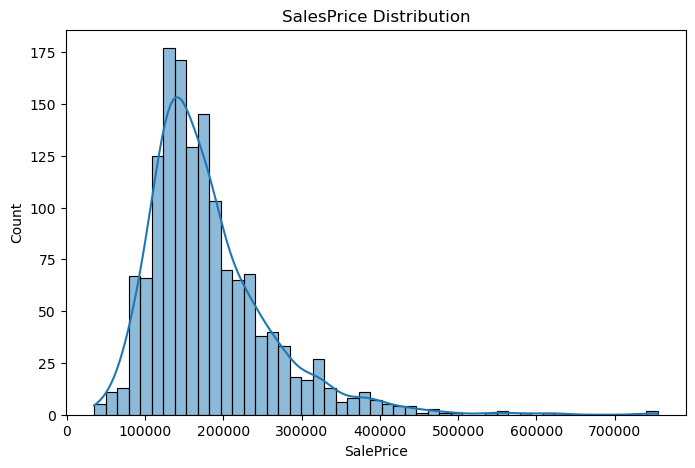

In [123]:
plt.figure(figsize=(8,5))
sns.histplot(data['SalePrice'], kde=True)
plt.title("SalesPrice Distribution")
plt.show()

In [124]:
# Apply log transformation
data['SalePrice'] = np.log1p(data['SalePrice'])

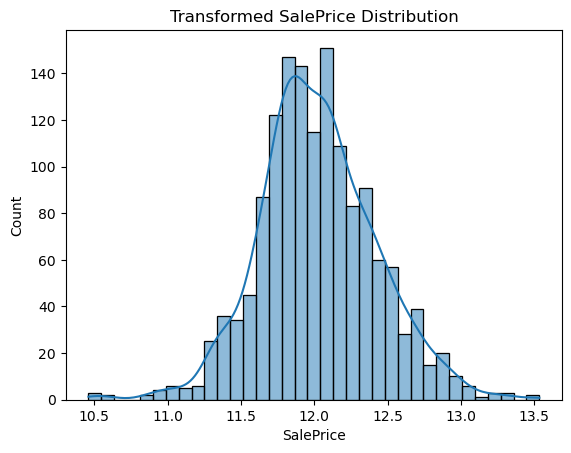

In [125]:
import matplotlib.pyplot as plt
import seaborn as sns

# Before (if you saved original)
# sns.histplot(original_data['SalePrice'], kde=True)

# After transformation
sns.histplot(data['SalePrice'], kde=True)
plt.title("Transformed SalePrice Distribution")
plt.show()

Log transformation reduces skewness in the target variable, 
making it more normally distributed. This helps regression models 
perform better and reduces the impact of extreme values.

# Encoding

Categorical variables are converted using one-hot encoding.

In [126]:
# Correlation Anlaysis

corr = data.corr(numeric_only=True)
corr['SalePrice'].sort_values(ascending=False).head(10)

SalePrice      1.000000
OverallQual    0.817185
TotalSF        0.777297
GrLivArea      0.700927
GarageCars     0.680625
GarageArea     0.650888
TotalBsmtSF    0.612134
1stFlrSF       0.596981
FullBath       0.594771
YearBuilt      0.586570
Name: SalePrice, dtype: float64

# Train-test Split

In [127]:
# Encoding
data = pd.get_dummies(data, drop_first=True)

# Define features and target
X = data.drop("SalePrice", axis=1)
y = data["SalePrice"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Check shape
print(X_train.shape, X_test.shape)

(1168, 248) (292, 248)


The dataset is split into 80% training data and 20% testing data. 
The training set is used to train the model, while the testing set 
is used to evaluate its performance on unseen data.

In [128]:
# Model creation
lr = LinearRegression()

# Training
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

## Model Building

Multiple regression models are built and trained to compare their performance 
and select the best model for house price prediction.

# Linear Regression

In [129]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("R2:", r2_score(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))

R2: 0.756576202224986
RMSE: 0.21313271815676677
MAE: 0.09648238718276757


# Decision Tree

In [130]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
print("Decision Tree R2:", r2_score(y_test, y_pred_dt))
print("Decision Tree RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))
print("Decision Tree MAE:", mean_absolute_error(y_test, y_pred_dt))

Decision Tree R2: 0.7766970388596683
Decision Tree RMSE: 0.20413423606356507
Decision Tree MAE: 0.1444134717045695


Decision Tree model was evaluated using R², RMSE, and to measure 
its performance and compare with other models.

# Random Forest

In [131]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("R2:", r2_score(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))

R2: 0.8803723030169521
RMSE: 0.14941165549124882
MAE: 0.09969566950203375


# XGBoost 

In [132]:
from xgboost import XGBRegressor

xgb = XGBRegressor()
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("R2:", r2_score(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))

R2: 0.8743315620478713
RMSE: 0.1531375572506172
MAE: 0.0994783712299963


Four regression models were trained: Linear Regression, Decision Tree, 
Random Forest, and XGBoost. These models were selected to compare 
simple, tree-based, and ensemble techniques for better performance.

# Gradient Boosting

In [133]:
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("R2:", r2_score(y_test, y_pred_gb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gb)))
print("MAE:", mean_absolute_error(y_test, y_pred_gb))

R2: 0.89247332723328
RMSE: 0.14165330460207018
MAE: 0.09372605844375825


# Cross Validation

In [134]:
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='r2')
print("Average CV Score:", cv_scores.mean())

Average CV Score: 0.8671083302934133


# Model Comparison Report

In [135]:
results = pd.DataFrame({
    "Model": ["Linear Regression",
              "Decision Tree",
              "Random Forest",
              "XGBoost",
              "Gradient Boosting"
    ],
    "R2 Score": [ 
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_dt),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_xgb),
        r2_score(y_test, y_pred_gb)
    ],
    "RMSE": [ 
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_dt)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_xgb)),
        np.sqrt(mean_squared_error(y_test, y_pred_gb))
    ],
    "MAE":[
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_dt),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_xgb),
        mean_absolute_error(y_test, y_pred_gb)
    ]
})

results.sort_values(by="R2 Score", ascending=False)
results.style.background_gradient(cmap='Blues')

,Model,R2 Score,RMSE,MAE
0,Linear Regression,0.756576,0.213133,0.096482
1,Decision Tree,0.776697,0.204134,0.144413
2,Random Forest,0.880372,0.149412,0.099696
3,XGBoost,0.874332,0.153138,0.099478
4,Gradient Boosting,0.892473,0.141653,0.093726


All models were compared using R², RMSE, and MAE to evaluate performance. 
This helps in selecting the best model based on accuracy and error metrics.

## Final Model Selection

Based on the evaluation metrics (R², RMSE, and MAE), Gradient Boosting Regressor 
was selected as the final model for this project.

### Reasons for Selection:

- It achieved the highest R² score among all models.
- It produced the lowest RMSE and MAE, indicating better accuracy.
- It handles complex non-linear relationships effectively.
- Hyperparameter tuning further improved its performance.
- It generalizes well and reduces overfitting compared to Decision Tree.

### Model Comparison Summary:

- Linear Regression performed moderately due to linear assumptions.
- Decision Tree showed signs of overfitting.
- Random Forest improved performance but was slightly less accurate.
- XGBoost performed well but was slightly below Gradient Boosting.
- Gradient Boosting provided the best balance between bias and variance.

## Residual Analysis

Residuals represent the difference between actual and predicted values. 
Analyzing residuals helps evaluate model performance and detect patterns.

In [136]:
# Calculate residuals
residuals = y_test - y_pred_best

# Plot distribution
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residuals")
plt.show()

NameError: name 'y_pred_best' is not defined

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(y_pred_best, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

Residual analysis shows that the errors are randomly distributed around zero, 
indicating that the model is performing well without significant bias.

# feature Importance

In [ ]:
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

feat_imp.head(10).plot(kind='bar')
plt.title("Top Importances Features")
plt.show()

# Improve Model to Reach with Hyperparamater Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)

param_grid = {
    'n_estimators': [200, 300, 400],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 3]
}

grid = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_gb = grid.best_estimator_

y_pred_best = best_gb.predict(X_test)

print("Best Parameters:", grid.best_params_)
print("Improved R2:", r2_score(y_test, y_pred_best))
print("Improved RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_best)))

## Conclusion

In this project, a machine learning model was developed to predict house prices 
based on various property features.

- Data preprocessing and cleaning were performed to handle missing values and inconsistencies.
- Feature engineering techniques improved the representation of important variables such as total area and house age.
- Log transformation was applied to the target variable to reduce skewness and improve model performance.
- Multiple models including Linear Regression, Decision Tree, Random Forest, XGBoost, and Gradient Boosting were trained and evaluated.

### Final Outcome:
- Gradient Boosting Regressor achieved the best performance based on R², RMSE, and MAE.
- The model successfully captured complex relationships between features and house prices.

### Key Insights:
- Overall quality, living area, and garage capacity are major factors influencing house prices.
- Feature engineering significantly improved prediction accuracy.

### Challenges Faced:
- Handling missing values in multiple features
- High dimensionality after one-hot encoding
- Avoiding overfitting in tree-based models
- Skewed distribution of SalePrice

### Future Scope:
- Deploy the model using Streamlit for real-time predictions
- Apply advanced models like LightGBM
- Perform further feature selection and dimensionality reduction

In [ ]:
import joblib

# Save the model
joblib.dump(best_gb, "house_price_model.pkl")